In [120]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import numpy as np
import flax

import matplotlib.pyplot as plt

from rich.progress import track

In [104]:
# Step 1: Define a simple feedforward neural network
class Student(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(12)(x)
        x = nn.sigmoid(x)
        x = nn.Dense(12)(x)
        return x
    
class Teacher(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(128)(x)
        x = nn.sigmoid(x)
        x = nn.Dense(128)(x)
        x = nn.sigmoid(x)
        x = nn.Dense(12)(x)
        return x

In [105]:
rng = jax.random.PRNGKey(np.random.randint(6431))
teacher = Teacher()
params = teacher.init(rng, jnp.ones([1, 10]))['params']

x = np.random.uniform(size=(1000, 10))
y = teacher.apply({"params": params}, x)

x_test = np.random.uniform(size=(100, 10))
y_test = teacher.apply({"params": params}, x_test)

In [106]:
# Step 2: Define the loss function and accuracy metric
def binary_cross_entropy_loss(logits, labels):
    labels = labels.reshape(-1, 1)
    logits = logits.reshape(-1, 1)
    loss = optax.sigmoid_binary_cross_entropy(logits=logits, labels=labels)
    return jnp.mean(loss)

def mse_loss(logits, labels):
    labels = labels.reshape(-1, 1)
    logits = logits.reshape(-1, 1)
    return jnp.mean(
        (logits - labels) ** 2
    )

def compute_metrics(logits, labels):
    loss = mse_loss(logits, labels)
    preds = jnp.round(jax.nn.sigmoid(logits))
    return {'loss': loss}

# Step 4: Define the training step
@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        logits = Student().apply({'params': params}, batch['features'])
        loss = mse_loss(logits, batch['labels'])
        return loss, logits

    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    metrics = compute_metrics(logits, batch['labels'])
    return state, metrics

# Step 5: Define the evaluation step
@jax.jit
def eval_step(state, batch):
    logits = Student().apply({'params': state.params}, batch['features'])
    metrics = compute_metrics(logits, batch['labels'])
    return metrics

# Step 6: Create dummy dataset
def get_decision_boundary_data(num_samples=1000):
    X = np.random.rand(num_samples, 2).astype(np.float32)  # 2D points
    y = (X[:, 1] > X[:, 0]).astype(np.float32)  # Class 1 if y > x, else class 0
    return X, y

# Step 7: Initialize the model and optimizer
def create_train_state(rng, learning_rate):
    model = Student()
    params = model.init(rng, jnp.ones([1, 10]))['params']
    tx = optax.sgd(learning_rate)
    return train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

In [161]:
def loss_op(params, data):
    logits = Student().apply({'params': params}, data['features'])
    return mse_loss(logits, data['labels'])

def fn_forward(params, data):
    logits = Student().apply({'params': params}, data['features'])
    return jnp.mean(logits.sum(axis=-1))

loss_grad_fn = jax.grad(loss_op)
fn_grad_fn = jax.grad(fn_forward)

def compute_kinetic_energy(params, data, lr, momenta):

    # Loss term
    loss_grads = loss_grad_fn(params, data)
    loss_grads = flax.traverse_util.flatten_dict(loss_grads)
    loss_grads = [jnp.ravel(array) for array in loss_grads.values()]
    loss_grads = lr * np.concatenate(loss_grads)

    loss_term = momenta - loss_grads

    # Fn Term
    fn_grads = fn_grad_fn(params, data)
    fn_grads = flax.traverse_util.flatten_dict(fn_grads)
    fn_grads = [jnp.ravel(array) for array in fn_grads.values()]
    fn_grads = np.concatenate(fn_grads)
    print(fn_grads.sum())


    return 0.5 * np.sum((fn_grads) ** 2), loss_grads

In [162]:
# Step 8: Training settings
num_epochs = 200
batch_size = 1000
learning_rate = 1e-1
train_loss = []
test_loss = []
train_ek = []
momenta = 0.

# Initialize the model and optimizer
rng = jax.random.PRNGKey(0)
state = create_train_state(rng, learning_rate)

# Dummy dataset
num_batches = len(x) // batch_size

# Step 9: Training loop
for epoch in track(range(num_epochs)):
    # Training
    for i in range(num_batches):
        batch_idx = np.random.choice(len(x), batch_size, replace=False)
        batch = {
            'features': jnp.array(x[batch_idx]),
            'labels': jnp.array(y[batch_idx])
        }
        state, train_metrics = train_step(state, batch)
    
    ek, momenta = compute_kinetic_energy(state.params, batch, learning_rate, momenta)
    train_ek.append(ek)

    # Validation (using the same training data for simplicity)
    val_batch = {'features': jnp.array(x_test), 'labels': jnp.array(y_test)}
    val_metrics = eval_step(state, val_batch)

    train_loss.append(train_metrics['loss'])
    test_loss.append(val_metrics['loss'])


Output()

77.26074
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:--

77.20535
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:--

77.20172
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:--

77.23913
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:--

...

81.7554
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━  92% 0:00:01

81.755295
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━  92% 0:00:01

81.75521
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━  96% 0:00:01

81.75512
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━  96% 0:00:01

81.75501
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━  96% 0:00:01

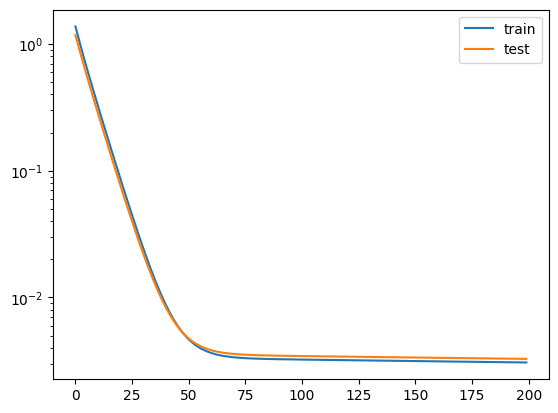

In [163]:
plt.plot(train_loss, label='train')
plt.plot(test_loss, label='test')

plt.legend()
plt.yscale("log")
plt.show()

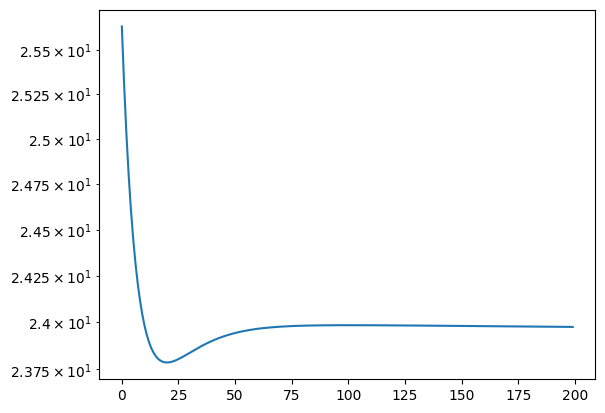

In [164]:
plt.plot(train_ek)
plt.yscale("log")